In [5]:
# STATISTICS MINI PROJECT : Unlocking Customer Insights: A Statistical Investigation
# Student : Sumeet Mehta
# November 7, 2025

# Import Libraries

import pandas as pd
import numpy as np
import statistics as stat
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [6]:
# Step 1 - Understand Your Data
# Load and preview the customer dataset
customer_data = pd.read_csv("/content/drive/MyDrive/Career247 DataScience/Statistics Mini Project/US_Customer_Insights_Dataset.csv")
customer_data.head(10)

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/2021,9/2/2024,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/2024,6/2/2024,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/2024,2/28/2025,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/2023,3/29/2025,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/2021,7/24/2022,139.68,1103
5,CUST10841,Stephen Cooke,Texas,PhD,Female,55,Yes,2,5/25/2022,4/4/2023,423.45,849
6,CUST10263,Rodney James,Ohio,High School,Non-Binary,61,No,0,11/20/2023,3/26/2024,402.96,492
7,CUST10117,Jeffrey Miles,Arizona,High School,Male,21,Yes,2,9/28/2020,7/9/2023,175.81,753
8,CUST10611,John Walsh,New York,Master,Male,74,No,2,5/15/2021,7/30/2022,320.48,1097
9,CUST10466,James Pope,New York,Master,Female,50,No,1,7/28/2021,1/28/2023,151.49,915


In [7]:
# Check data types, unique values, and presence of nulls.

print("Shape: ",customer_data.shape)
print("==================================================================")
print(customer_data.info())
print("==================================================================")
print(customer_data.describe())
print("==================================================================")
print("Null Values:\n",customer_data.isnull().sum() ) # Check for null values
print("==================================================================")
print("Duplicates:",customer_data.duplicated().sum() ) # Check for duplicates
print("==================================================================")



Shape:  (10675, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10675 non-null  object 
 1   Name                      10675 non-null  object 
 2   State                     10675 non-null  object 
 3   Education                 10675 non-null  object 
 4   Gender                    10675 non-null  object 
 5   Age                       10675 non-null  int64  
 6   Married                   10675 non-null  object 
 7   NumPets                   10675 non-null  int64  
 8   JoinDate                  10675 non-null  object 
 9   TransactionDate           10675 non-null  object 
 10  MonthlySpend              10675 non-null  float64
 11  DaysSinceLastInteraction  10675 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 1000.9+ KB
None
                Age       NumPe

In [8]:
# Understand which variables are categorical and which are numerical.
# Numerical Variables :  Age,       NumPets,  MonthlySpend,  DaysSinceLastInteraction
# Categorical Variables : CustomerID, Name, State, Education, Gender, Married, JoinDate, TransactionDate

customer_data.head(5)

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/2021,9/2/2024,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/2024,6/2/2024,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/2024,2/28/2025,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/2023,3/29/2025,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/2021,7/24/2022,139.68,1103


In [9]:
# Step 2 - Descriptive Statistics
# Compute Mean, median, std dev for Age,NumPets, MonthlySpend, DaysSinceLastInteraction
customer_data.describe()

,Age,NumPets,MonthlySpend,DaysSinceLastInteraction
count,10675.000000,10675.000000,10675.000000,10675.000000
mean,49.474567,1.340515,331.610315,538.469883
std,18.221365,1.150849,225.799253,398.766747
min,18.000000,0.000000,3.890000,1.000000
25%,35.000000,0.000000,165.495000,218.000000
50%,49.000000,1.000000,282.110000,445.000000
75%,66.000000,2.000000,443.255000,788.500000
max,80.000000,4.000000,1740.420000,1791.000000


In [10]:
print("Age                      - Median : ", customer_data["Age"].median())
print("MonthlySpend             - Median : ", customer_data["MonthlySpend"].median())
print("DaysSinceLastInteraction - Median : ", customer_data["DaysSinceLastInteraction"].median())

Age                      - Median :  49.0
MonthlySpend             - Median :  282.11
DaysSinceLastInteraction - Median :  445.0


In [11]:
# Compute Mode for categorical variables: Gender, Education, Married
print ("Gender     - Mode : ", stat.mode (customer_data["Gender"]))
print ("Value_counts :", customer_data["Gender"].value_counts(),"\n")

print ("Education  - Mode : ", stat.mode (customer_data["Education"]))
print ("Value_counts :", customer_data["Education"].value_counts(),"\n")

print ("Married    - Mode : ", stat.mode (customer_data["Married"]))
print ("Value_counts :", customer_data["Married"].value_counts(),"\n")

Gender     - Mode :  Male
Value_counts : Gender
Male          3791
Non-Binary    3471
Female        3413
Name: count, dtype: int64 

Education  - Mode :  Master
Value_counts : Education
Master         2269
Associate      2153
Bachelor       2127
High School    2120
PhD            2006
Name: count, dtype: int64 

Married    - Mode :  No
Value_counts : Married
No     5583
Yes    5092
Name: count, dtype: int64 



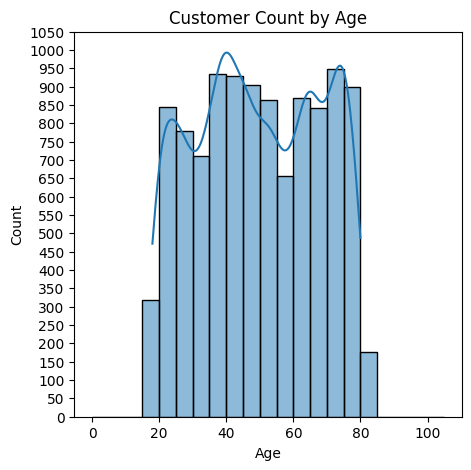

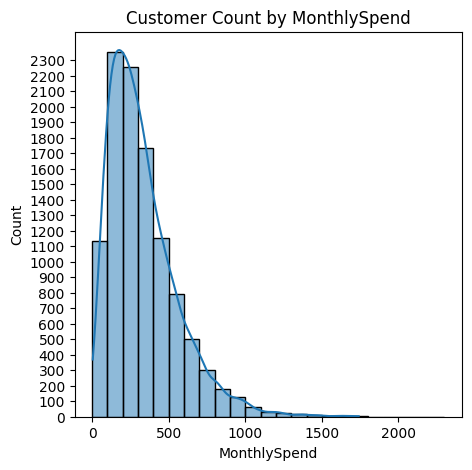

In [12]:
# Step 3: Data Visualization
# Plot histograms for Age, MonthlySpend

plt.figure(figsize=(5,5))
a = sns.histplot(customer_data['Age'],kde=True,bins=np.arange(0,110,5))
a.set_title("Customer Count by Age")
plt.yticks(np.arange(0,1100,50))
plt.show()

plt.figure(figsize=(5,5))
a = sns.histplot(customer_data['MonthlySpend'],kde=True,bins=np.arange(0,2400,100))
a.set_title("Customer Count by MonthlySpend")
plt.yticks(np.arange(0,2400,100))
plt.show()




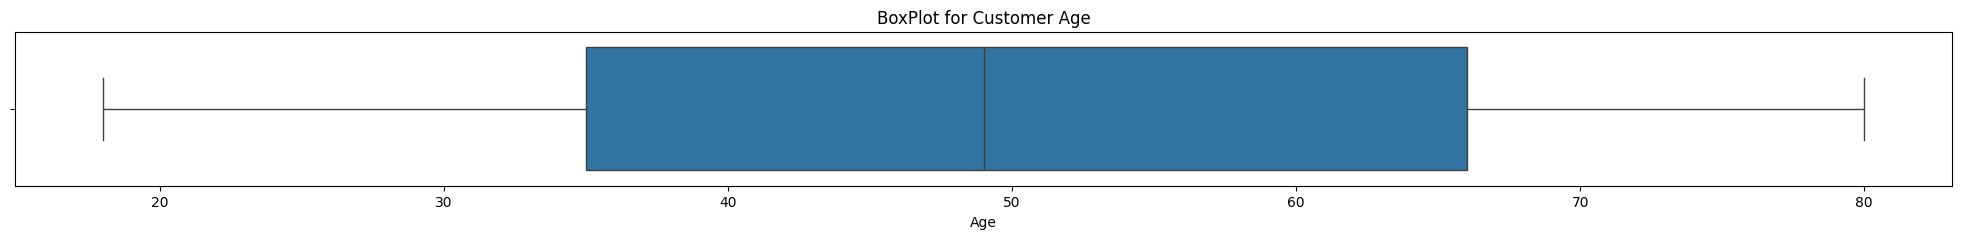

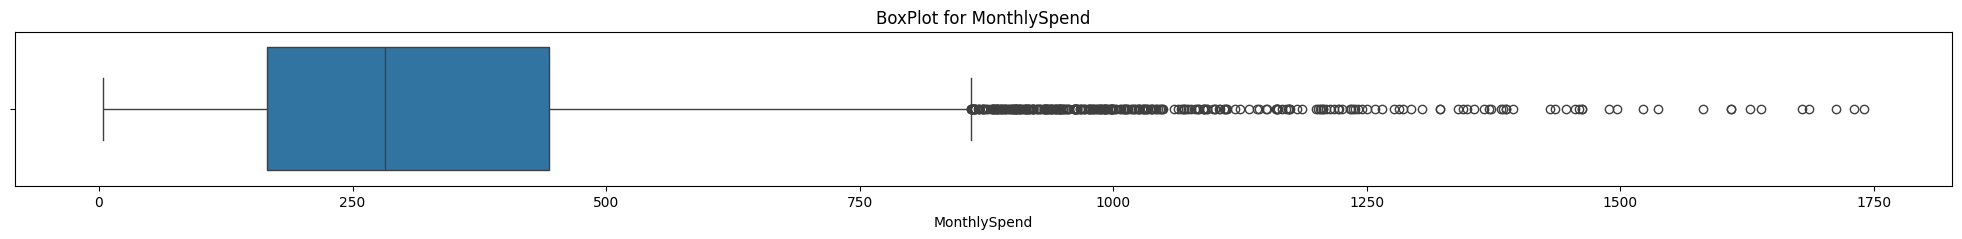

In [13]:

# Box Plots  for Age, MonthlySpend

plt.figure(figsize=(25,2))
b = sns.boxplot(x=customer_data['Age'])
b.set_title("BoxPlot for Customer Age")
plt.show()

plt.figure(figsize=(25,2))
b = sns.boxplot(x=customer_data['MonthlySpend'])
b.set_title("BoxPlot for MonthlySpend")
plt.show()

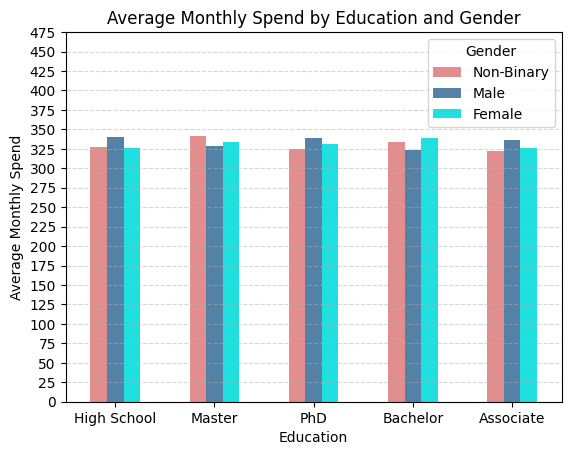

In [14]:
# Create a bar chart for Education and Gender

bar=sns.barplot(x=customer_data['Education'],y=customer_data['MonthlySpend'],errorbar=None,hue=customer_data['Gender'],
            palette={'Non-Binary':'lightcoral','Male':'steelblue','Female':'cyan'},width=0.5)

bar.set_yticks(np.arange(0,500,25))
bar.grid(axis='y',ls='--',alpha=0.5)
bar.legend(title='Gender')
bar.set_xlabel("Education")
bar.set_ylabel("Average Monthly Spend")
bar.set_title("Average Monthly Spend by Education and Gender")
#sns.despine() # do not display top and right most lines
plt.show()

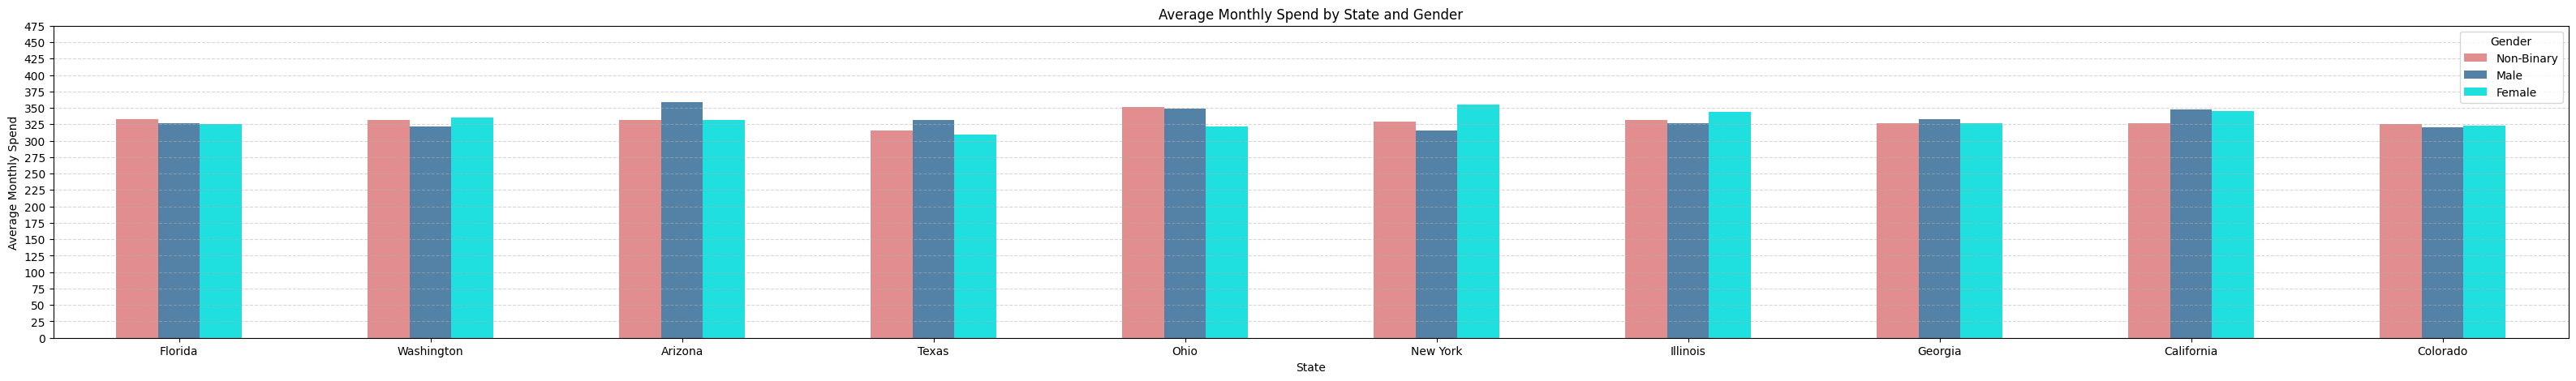

In [15]:
# Create a bar chart for State and Gender (Monthly Spend)
plt.figure(figsize=(40,5))
bar=sns.barplot(x=customer_data['State'],y=customer_data['MonthlySpend'],errorbar=None,hue=customer_data['Gender'],
            palette={'Non-Binary':'lightcoral','Male':'steelblue','Female':'cyan'}, width=0.5)

bar.set_yticks(np.arange(0,500,25))
bar.grid(axis='y',ls='--',alpha=0.5)
bar.legend(title='Gender')
bar.set_xlabel("State")
bar.set_ylabel("Average Monthly Spend")
bar.set_title("Average Monthly Spend by State and Gender")
#sns.despine() # do not display top and right most lines
plt.show()

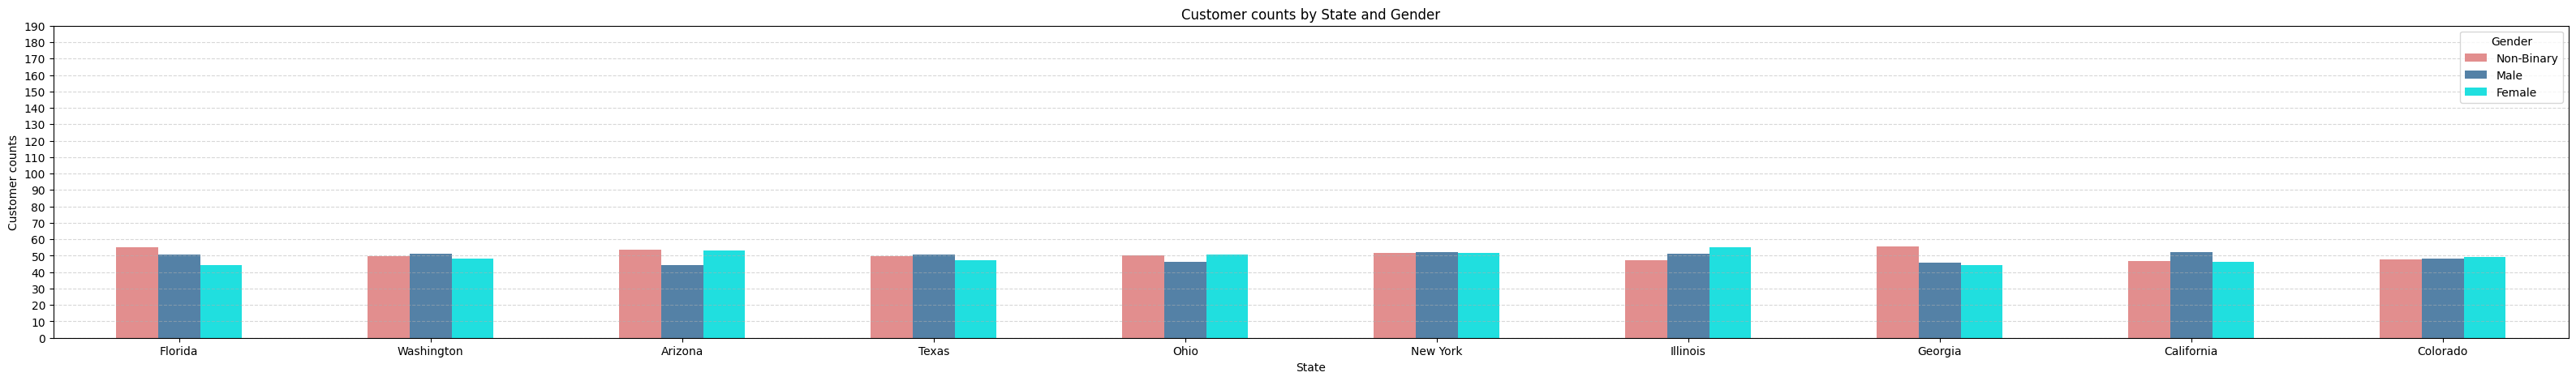

In [16]:
# Create a bar chart for State and Gender (Customer count)
plt.figure(figsize=(40,5))
bar=sns.barplot(x=customer_data['State'],y=customer_data['Age'],errorbar=None,hue=customer_data['Gender'],
            palette={'Non-Binary':'lightcoral','Male':'steelblue','Female':'cyan'},width=0.5)

bar.set_yticks(np.arange(0,200,10))
bar.grid(axis='y',ls='--',alpha=0.5)
bar.legend(title='Gender')
bar.set_xlabel("State")
bar.set_ylabel("Customer counts")
bar.set_title("Customer counts by State and Gender")
#sns.despine() # do not display top and right most lines
plt.show()

In [17]:
customer_data['State'].value_counts()


,count
State,
California,1180
Florida,1152
Ohio,1145
Arizona,1087
New York,1085
Georgia,1080
Washington,1030
Colorado,1014
Texas,997


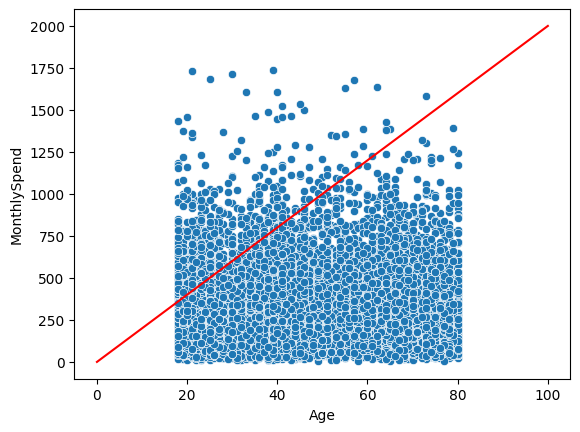

In [18]:
# Scatterplot: Age vs MonthlySpend
sns.scatterplot(data=customer_data,x='Age',y='MonthlySpend')
plt.plot([0,100],[0,2000],color='r')
plt.show()

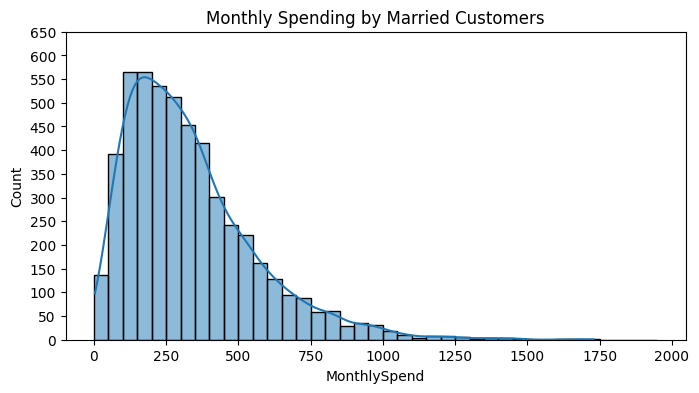

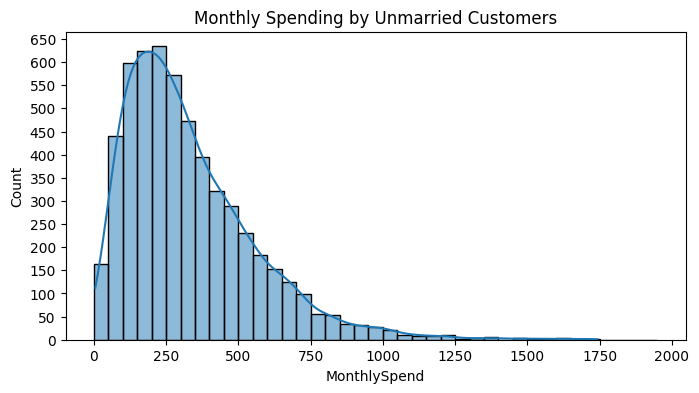

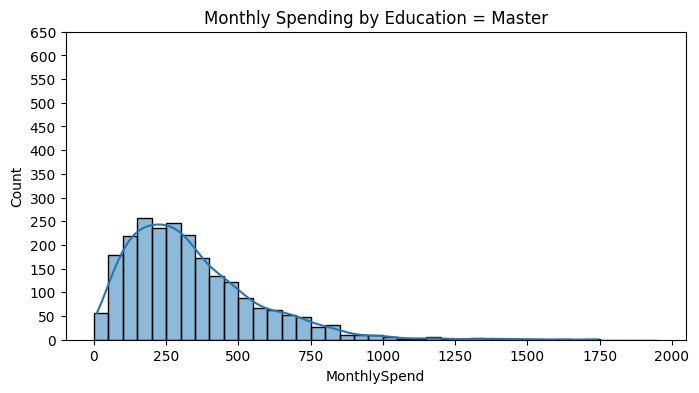

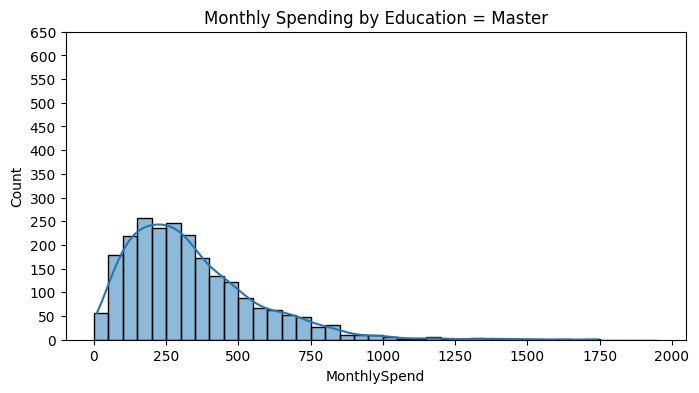

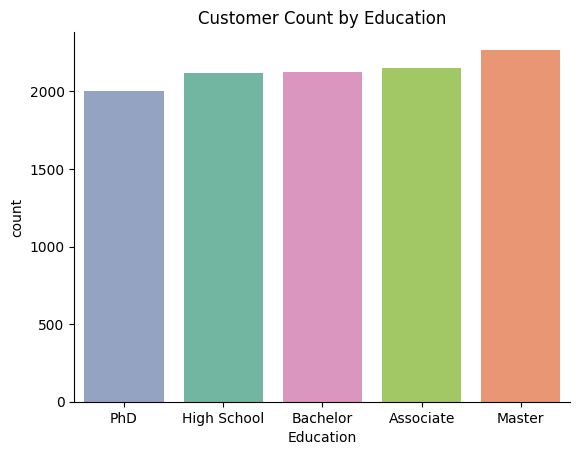

In [19]:
# KDE: Spending behavior by education level or marital status

plt.figure(figsize=(8,4))
a = sns.histplot(customer_data[customer_data["Married"] == 'Yes']["MonthlySpend"],kde=True,bins=np.arange(0,2000,50))
a.set_title("Monthly Spending by Married Customers")
plt.yticks(np.arange(0,700,50))
plt.show()

plt.figure(figsize=(8,4))
a = sns.histplot(customer_data[customer_data["Married"] == 'No']["MonthlySpend"],kde=True,bins=np.arange(0,2000,50))
a.set_title("Monthly Spending by Unmarried Customers")
plt.yticks(np.arange(0,700,50))
plt.show()

plt.figure(figsize=(8,4))
a = sns.histplot(customer_data[customer_data["Education"] == 'Master']["MonthlySpend"],kde=True,bins=np.arange(0,2000,50))
a.set_title("Monthly Spending by Education = Master")
plt.yticks(np.arange(0,700,50))
plt.show()

plt.figure(figsize=(8,4))
a = sns.histplot(customer_data[customer_data["Education"] == 'Master']["MonthlySpend"],kde=True,bins=np.arange(0,2000,50))
a.set_title("Monthly Spending by Education = Master")
plt.yticks(np.arange(0,700,50))
plt.show()

b=sns.countplot(x=customer_data['Education'],data=customer_data, hue=customer_data['Education'],palette='Set2', order=customer_data['Education'].value_counts(ascending=True).index)
b.set_title("Customer Count by Education")
sns.despine()
plt.show()

In [35]:
# Step 4: Bivariate Analysis
# Correlation matrix (numeric variables)

customer_data_numeric=customer_data.drop(['CustomerID','Name','State','Education','Gender','Married','JoinDate','TransactionDate'], axis=1)  # drop categorical data columns
print("Correlation Matrix (numeric variables)")
customer_data_numeric.corr()

Correlation Matrix (numeric variables)


,Age,NumPets,MonthlySpend,DaysSinceLastInteraction
Age,1.000000,-0.023035,-0.012323,-0.003970
NumPets,-0.023035,1.000000,0.020647,-0.055227
MonthlySpend,-0.012323,0.020647,1.000000,0.006081
DaysSinceLastInteraction,-0.003970,-0.055227,0.006081,1.000000


In [36]:
# Crosstab of Gender vs Married
res = pd.crosstab(customer_data["Gender"],customer_data["Married"], margins=True,margins_name = 'Totals')
res


Married,No,Yes,Totals
Gender,,,
Female,1797,1616,3413
Male,1892,1899,3791
Non-Binary,1894,1577,3471
Totals,5583,5092,10675


In [43]:
# Grouped stats: Average MonthlySpend by State, Education, Gender

customer_data.groupby(["State","Education","Gender"], as_index=False)['MonthlySpend'].mean().round(2)



,State,Education,Gender,MonthlySpend
0,Arizona,Associate,Female,329.19
1,Arizona,Associate,Male,360.35
2,Arizona,Associate,Non-Binary,316.10
3,Arizona,Bachelor,Female,330.91
4,Arizona,Bachelor,Male,344.25
...,...,...,...,...
145,Washington,Master,Male,305.58
146,Washington,Master,Non-Binary,318.77
147,Washington,PhD,Female,368.06
148,Washington,PhD,Male,333.00


In [112]:
# Step 5: Formulate Hypotheses
# Step 6: Run Hypothesis Tests

# Business Purpose: Turn business questions into statistical tests.
# Business Question

# Do males and females spend differently?   # Independent t-test
# H0 (Null Hypothesis)      : Males & Females spending is similar
# H1 (Alternate hypothesis) : Males & Females spending is different

# Filter data based on Gender (Male/Female)
customer_data_male   = customer_data[customer_data['Gender'] == 'Male']
customer_data_female = customer_data[customer_data['Gender'] == 'Female']

# Perform the independent samples t-test
# equal_var=True assumes equal population variances (Student's t-test)

t_statistic, p_value = stats.ttest_ind(customer_data_male['MonthlySpend'], customer_data_female['MonthlySpend'], equal_var=True)


print("Results of performing the independent samples t-test")
print(f"Male   MonthlySpend Mean: {np.mean(customer_data_male['MonthlySpend']):.2f}")
print(f"Female MonthlySpend Mean: {np.mean(customer_data_female['MonthlySpend']):.2f}")
print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

# Define significance level
alpha = 0.05

# Interpret the results
if p_value < alpha:
    print("Decision: Reject the null hypothesis. There is a significant difference between the group means.")
else:
    print("Decision: Fail to reject the null hypothesis. There is no significant difference between the group means.")


Results of performing the independent samples t-test
Male   MonthlySpend Mean: 333.17
Female MonthlySpend Mean: 331.36
T-statistic: 0.339
P-value: 0.734
Decision: Fail to reject the null hypothesis. There is no significant difference between the group means.


In [21]:
# Does education level impact average monthly spend?  # One-way ANOVA test

# H0 (Null Hypothesis)      : Average monthly spending by Education level is similar
# H1 (Alternate hypothesis) : Average monthly spending by Education level is NOT similar

from scipy.stats import f_oneway

# Filter data based on Education level
customer_data_HS          = customer_data[customer_data['Education'] == 'High School']
customer_data_Associate   = customer_data[customer_data['Education'] == 'Associate']
customer_data_Bachelor    = customer_data[customer_data['Education'] == 'Bachelor']
customer_data_Master      = customer_data[customer_data['Education'] == 'Master']
customer_data_PhD         = customer_data[customer_data['Education'] == 'PhD']

f_statistic, p_value = f_oneway(customer_data_HS['MonthlySpend'],
                                customer_data_Associate['MonthlySpend'],
                                customer_data_Bachelor['MonthlySpend'],
                                customer_data_Master['MonthlySpend'],
                                customer_data_PhD['MonthlySpend']
                                )



print("Results of performing the One-Way ANOVA test")
print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.2f}")

# Define significance level
alpha = 0.05

# Interpret the results
if p_value < alpha:
    print("Decision: Reject the null hypothesis. There is a significant difference between the group means based on Education level")
else:
    print("Decision: Fail to reject the null hypothesis. There is no significant difference between the group means based on Education level.")



Results of performing the One-Way ANOVA test
F-statistic: 0.23
P-value: 0.92
Decision: Fail to reject the null hypothesis. There is no significant difference between the group means based on Education level.


In [22]:
# Is marital status related to the number of pets owned? [Only for DS Students] # Chi-squared test
# H0 (Null Hypothesis)      : Marital status is related to the Number of Pets
# H1 (Alternate hypothesis) : Marital status is NOT related to the Number of Pets

from scipy.stats import chi2_contingency

# Define the contingency table (observed frequencies)
# Rows represent Married (e.g., Yes, No), columns represent NumPets
# data = np.array([[1205 1770 1242  598  277],  # Married = Yes : Frequency of each NumPets count 0,1,2,3,4
#                  [1839 1435 1504  509  296]]) # Married = No  : Frequency of each NumPets count 0,1,2,3,4


data = np.array ([customer_data[customer_data['Married'] == 'Yes']['NumPets'].value_counts().sort_index().to_list(),
                  customer_data[customer_data['Married'] == 'No' ]['NumPets'].value_counts().sort_index().to_list()]
                 )

print ("Display Customer data frequency: \n", data.view())

# Perform the Chi-square test
print ("\nPerform the Chi-square test \n")
stat, p, dof, expected = chi2_contingency(data)

# Interpret the p-value using Significance level
alpha = 0.05

print(f"Chi-square statistic: {stat:.2f}")
print(f"P-value: {p:.3f}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies table:")
print(expected.round(0))

if p <= alpha:
    print("\nDecision: Reject the null hypothesis : There is significant association between Marital status and Numpets.")
else:
    print("\nDecision: Fail to reject the null hypothesis : There is no significant association between Marital status and Numpets.")

Display Customer data frequency: 
 [[1205 1770 1242  598  277]
 [1839 1435 1504  509  296]]

Perform the Chi-square test 

Chi-square statistic: 177.64
P-value: 0.000
Degrees of freedom: 4
Expected frequencies table:
[[1452. 1529. 1310.  528.  273.]
 [1592. 1676. 1436.  579.  300.]]

Decision: Reject the null hypothesis : There is significant association between Marital status and Numpets.


In [13]:
# Are older people less active? # Correlation (Age vs DaysSinceLastInteraction)
# Null Hypothesis (H₀)       :  Older people are less active
# Alternative Hypothesis (H₁):  There is no significant correlation between Age and interaction


# drop categorical data columns
cols = [5,11]  # Columns Age & DaysSinceLastInteraction
customer_data_corr = customer_data[customer_data.columns[cols]]

# Correlation Matrix for Age and DaysSinceLastInteraction
print("Correlation Matrix (Age vs DaysSinceLastInteraction)")
customer_data_corr.corr()

# There is very weak correlation (-0.00397) between Age and DaysSinceLastInteraction
# Decision: Reject the Null Hypothesis

Correlation Matrix (Age vs DaysSinceLastInteraction)


,Age,DaysSinceLastInteraction
Age,1.00000,-0.00397
DaysSinceLastInteraction,-0.00397,1.00000


In [23]:
# Does state-wise spend vary significantly? # ANOVA
# Null Hypothesis (H₀)       : The means of MonthlySpend across the States are nearly equal
# Alternative Hypothesis (H₁): The mean of MonthlySpend for at least one State varies significantly

from scipy.stats import f_oneway

# Filter customer data based on State
customer_data_California     = customer_data[customer_data['State'] == 'California']
customer_data_Florida        = customer_data[customer_data['State'] == 'Florida']
customer_data_Ohio           = customer_data[customer_data['State'] == 'Ohio']
customer_data_Arizona        = customer_data[customer_data['State'] == 'Arizona']
customer_data_New_York       = customer_data[customer_data['State'] == 'New York']
customer_data_Georgia        = customer_data[customer_data['State'] == 'Georgia']
customer_data_Washington     = customer_data[customer_data['State'] == 'Washington']
customer_data_Colorado       = customer_data[customer_data['State'] == 'Colorado']
customer_data_Texas          = customer_data[customer_data['State'] == 'Texas']
customer_data_Illinois       = customer_data[customer_data['State'] == 'Illinois']

f_statistic, p_value = f_oneway(customer_data_California['MonthlySpend'],
                                customer_data_Florida['MonthlySpend'],
                                customer_data_Ohio['MonthlySpend'],
                                customer_data_Arizona['MonthlySpend'],
                                customer_data_New_York['MonthlySpend'],
                                customer_data_Georgia['MonthlySpend'],
                                customer_data_Washington['MonthlySpend'],
                                customer_data_Colorado['MonthlySpend'],
                                customer_data_Texas['MonthlySpend'],
                                customer_data_Illinois['MonthlySpend']
                                )


print("\nResults of performing the One-Way ANOVA test")
print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.2f}")

# Define significance level
alpha = 0.05

# Interpret the results
if p_value < alpha:
    print("Decision: Reject the null hypothesis. The mean of MonthlySpend for at least one State varies significantly.")
else:
    print("Decision: Fail to reject the null hypothesis. The means of MonthlySpend across the States are nearly equal.  ")



Results of performing the One-Way ANOVA test
F-statistic: 1.12
P-value: 0.35
Decision: Fail to reject the null hypothesis. The means of MonthlySpend across the States are nearly equal.  


In [24]:
# Step 7: Present Business Insights
# Business Purpose: Translate stats into strategy.

# Takeaways
# The average monthly spend for Males and Females customers is similar.
# The average monthly spend by Education level of customers is similar.
# The average monthly spend by State is similar.
# Marital status of customers is NOT related to the Number of Pets.
# The correlation between Age and Days Since Last Interaction is very weak.

# Strategy: The customer demographics like gender, education, age and state does not impact the monthly spend.
#           A common marketing campaign aiming for all customer demographics can be decided.

